# Programming Assignment 1 — Segmentação de Instâncias

In [78]:
import os
import sys
import time
import utils
import torch
import numpy as np

sys.path.append(os.path.abspath('src'))

device = utils.get_device()
print(f"Dispositivo: {device}")

Dispositivo: cuda


In [50]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")

Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético

In [51]:
# Parte 0 — Dataset Sintético (670 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=670, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42, stratify=False)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")

Dataset Sintético | Treino: 468 | Val: 101 | Teste: 101


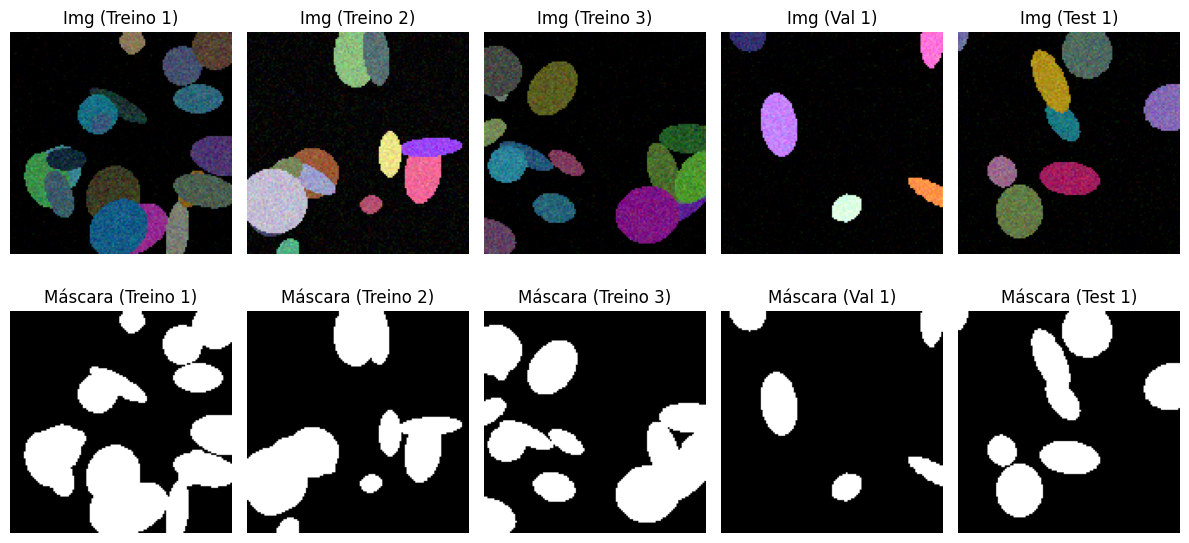

In [52]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)

In [53]:
# Parte 0 — Treinamento ResUNet
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
t0 = time.time()
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)
t1 = time.time()
print(f"Treinamento concluído em {t1 - t0:.2f} segundos.")

Epoch [ 1/10] | Train Loss: 0.2118 | Val Loss: 0.1347
Epoch [ 2/10] | Train Loss: 0.0949 | Val Loss: 0.0677
Epoch [ 3/10] | Train Loss: 0.0512 | Val Loss: 0.0373
Epoch [ 4/10] | Train Loss: 0.0306 | Val Loss: 0.0239
Epoch [ 5/10] | Train Loss: 0.0201 | Val Loss: 0.0163
Epoch [ 6/10] | Train Loss: 0.0141 | Val Loss: 0.0116
Epoch [ 7/10] | Train Loss: 0.0104 | Val Loss: 0.0087
Epoch [ 8/10] | Train Loss: 0.0080 | Val Loss: 0.0067
Epoch [ 9/10] | Train Loss: 0.0063 | Val Loss: 0.0054
Epoch [10/10] | Train Loss: 0.0051 | Val Loss: 0.0044
Treinamento concluído em 36.12 segundos.


In [54]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")

[Sintético] Mean Dice: 1.0000 | Mean IoU: 0.9999


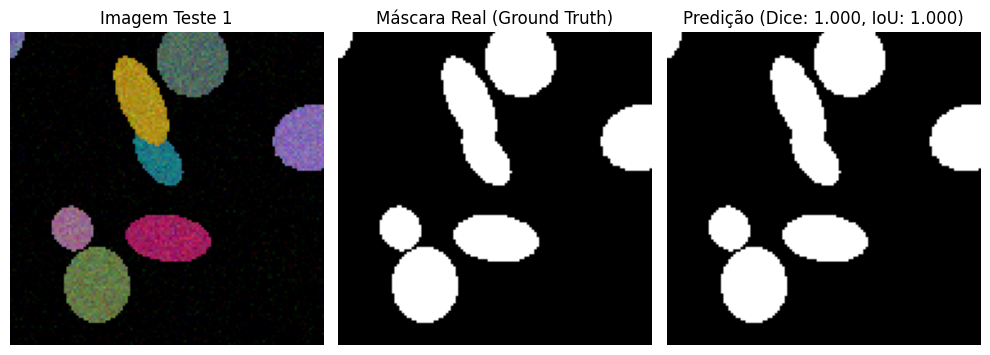

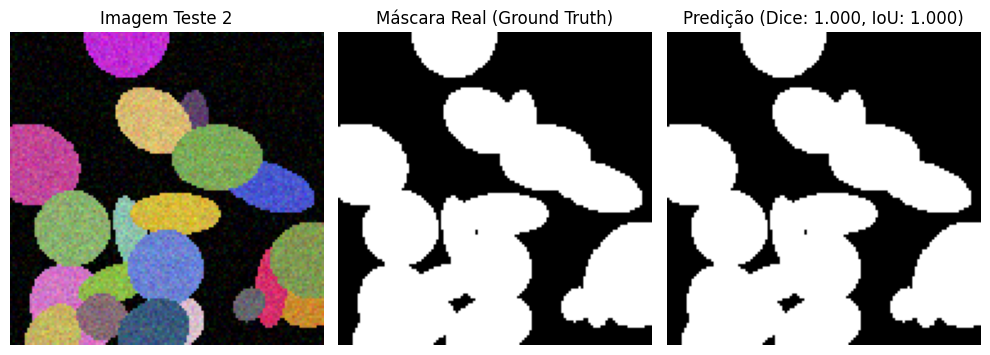

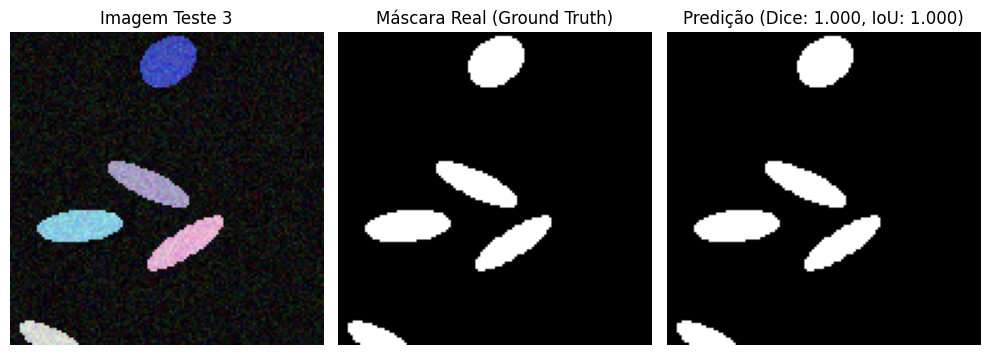

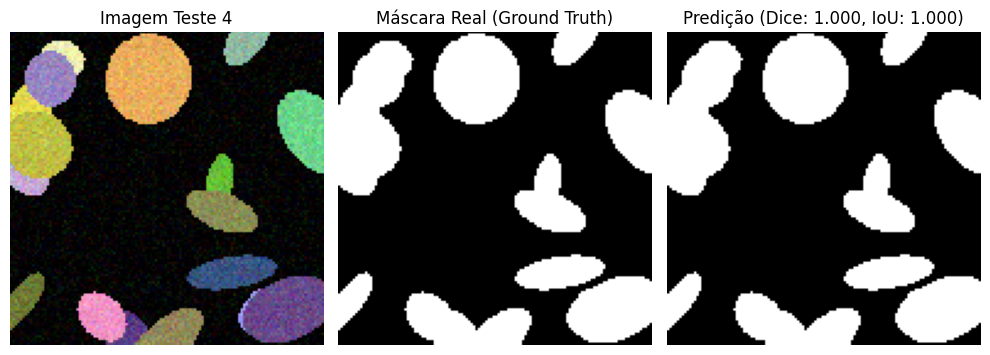

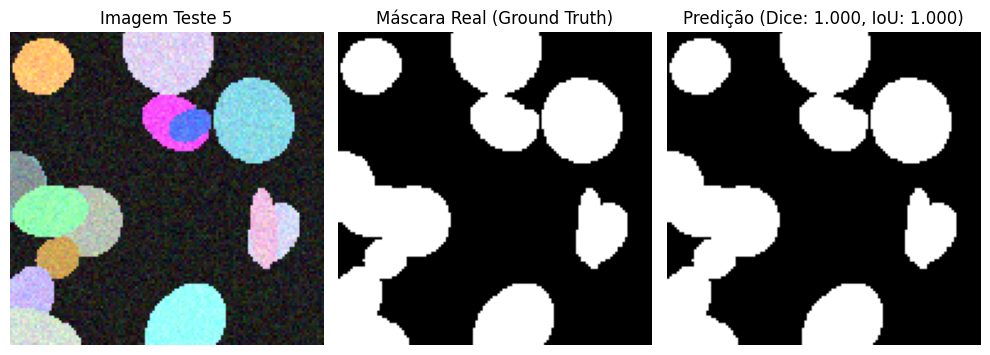

In [55]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)

--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)

**Dados escolhidos:** Opção A

Microscopia com máscara individual por núcleo.

In [56]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")

Split estratificado por modalidade (Total: 670):
  Treino (468): {np.str_('fluorescence'): 382, np.str_('brightfield_color'): 74, np.str_('brightfield_gray'): 12}
  Validação (101): {np.str_('fluorescence'): 82, np.str_('brightfield_color'): 16, np.str_('brightfield_gray'): 3}
  Teste (101): {np.str_('fluorescence'): 82, np.str_('brightfield_color'): 16, np.str_('brightfield_gray'): 3}
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


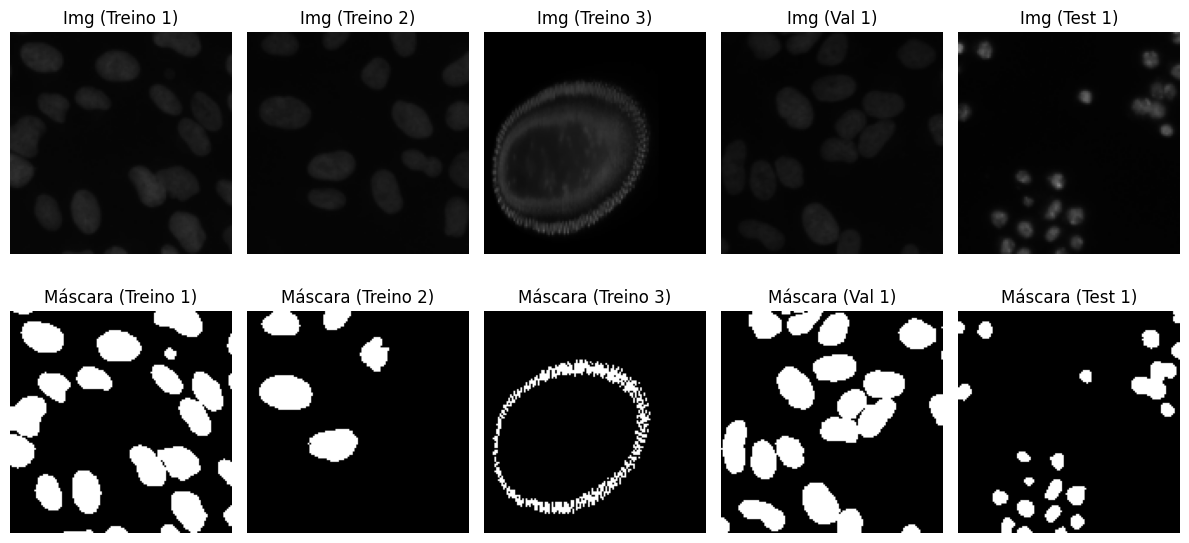

In [57]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)

In [58]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\nMean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")

Epoch [ 1/10] | Train Loss: 0.5414 | Val Loss: 0.5370
Epoch [ 2/10] | Train Loss: 0.3665 | Val Loss: 0.3655
Epoch [ 3/10] | Train Loss: 0.2859 | Val Loss: 0.2791
Epoch [ 4/10] | Train Loss: 0.2255 | Val Loss: 0.2340
Epoch [ 5/10] | Train Loss: 0.1832 | Val Loss: 0.1960
Epoch [ 6/10] | Train Loss: 0.1518 | Val Loss: 0.1442
Epoch [ 7/10] | Train Loss: 0.1303 | Val Loss: 0.1184
Epoch [ 8/10] | Train Loss: 0.1140 | Val Loss: 0.1171
Epoch [ 9/10] | Train Loss: 0.1029 | Val Loss: 0.0951
Epoch [10/10] | Train Loss: 0.0929 | Val Loss: 0.1014

Mean Dice: 0.8662 | Mean IoU: 0.7883


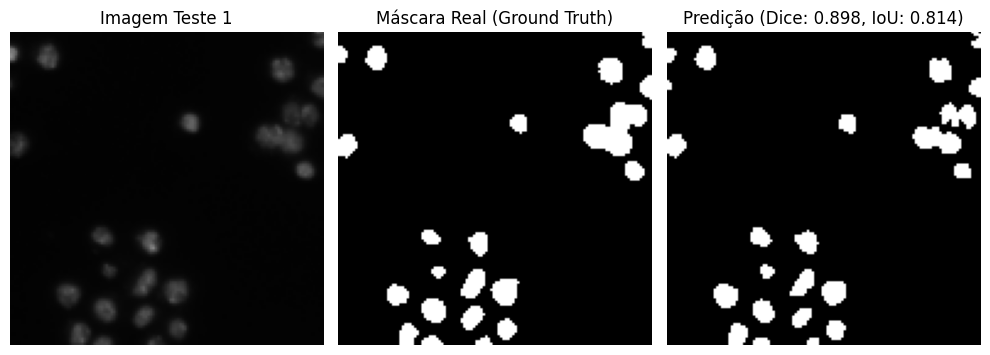

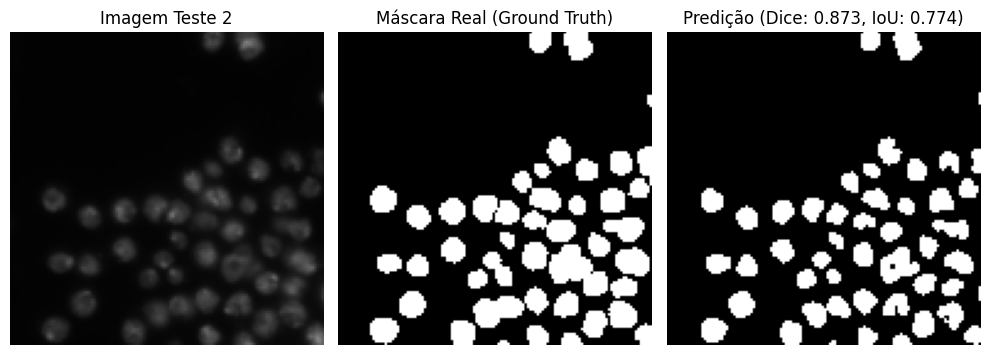

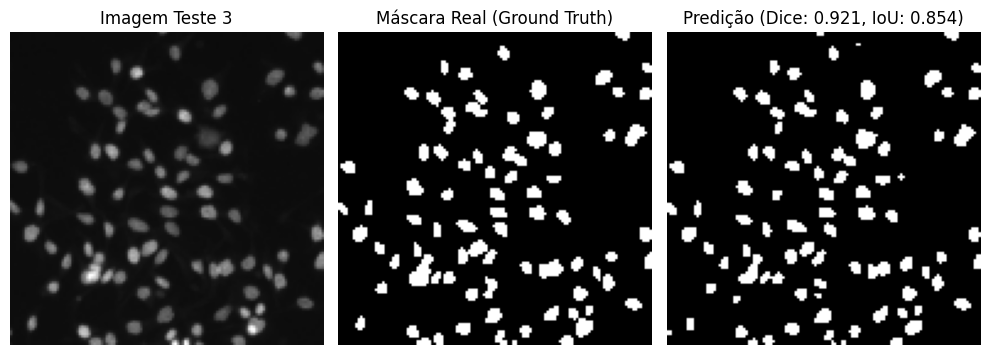

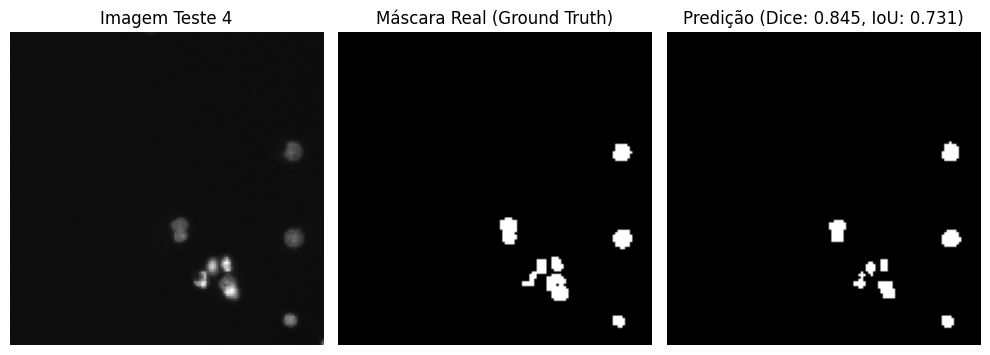

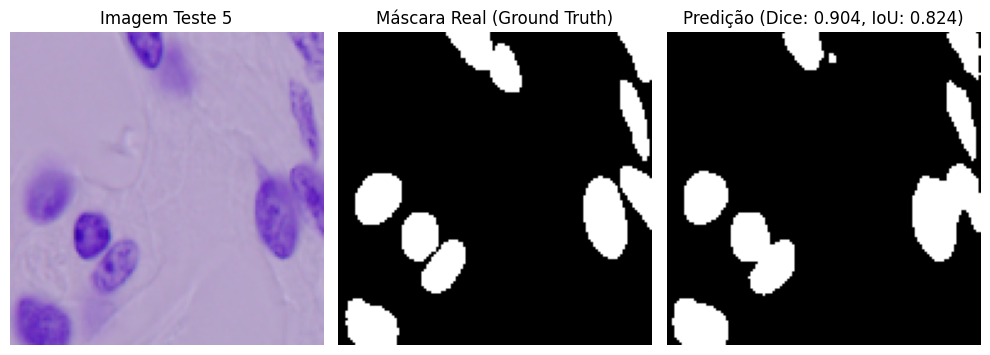

In [59]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)

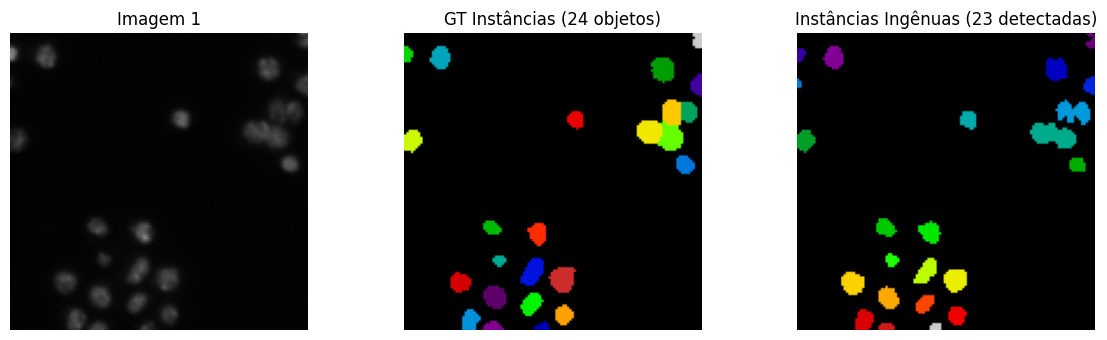

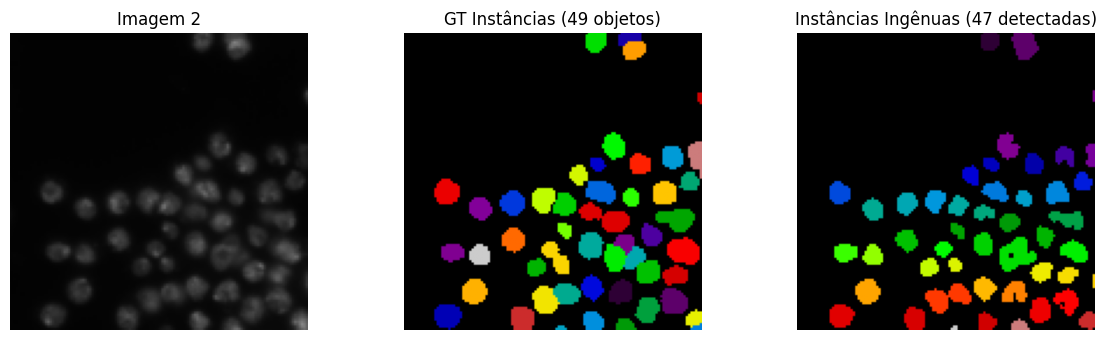

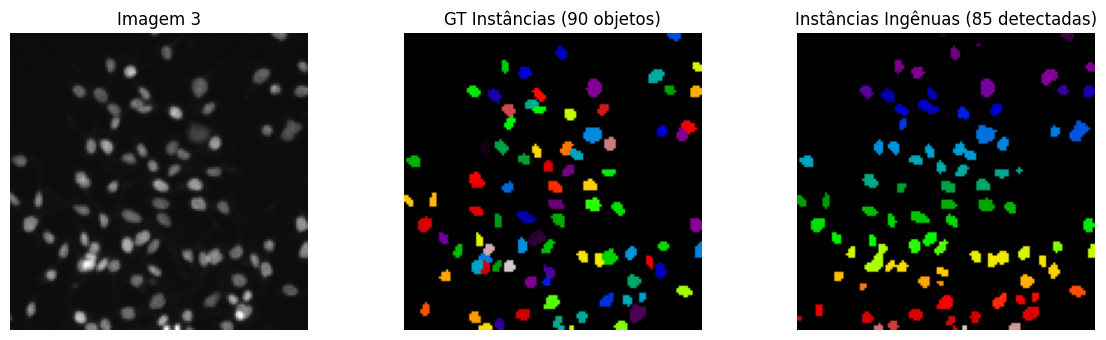

In [60]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)

In [61]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")
# TODO: Implementar a avaliação por instâncias para o dataset sintético, se necessário.
# TODO: Histograma de Erro Absoluto de Contagem por Imagem.


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6315
  IoU = 0.55 : AP = 0.5964
  IoU = 0.60 : AP = 0.5718
  IoU = 0.65 : AP = 0.5443
  IoU = 0.70 : AP = 0.5086
  IoU = 0.75 : AP = 0.4609
  IoU = 0.80 : AP = 0.4169
  IoU = 0.85 : AP = 0.3264
  IoU = 0.90 : AP = 0.2128
  IoU = 0.95 : AP = 0.0663

--> mAP@[.50:.95] Final: 0.4336
--> Erro Absoluto Médio de Contagem por Imagem: 11.30 objetos


In [62]:
#TODO: Documentar a regra Hungarian

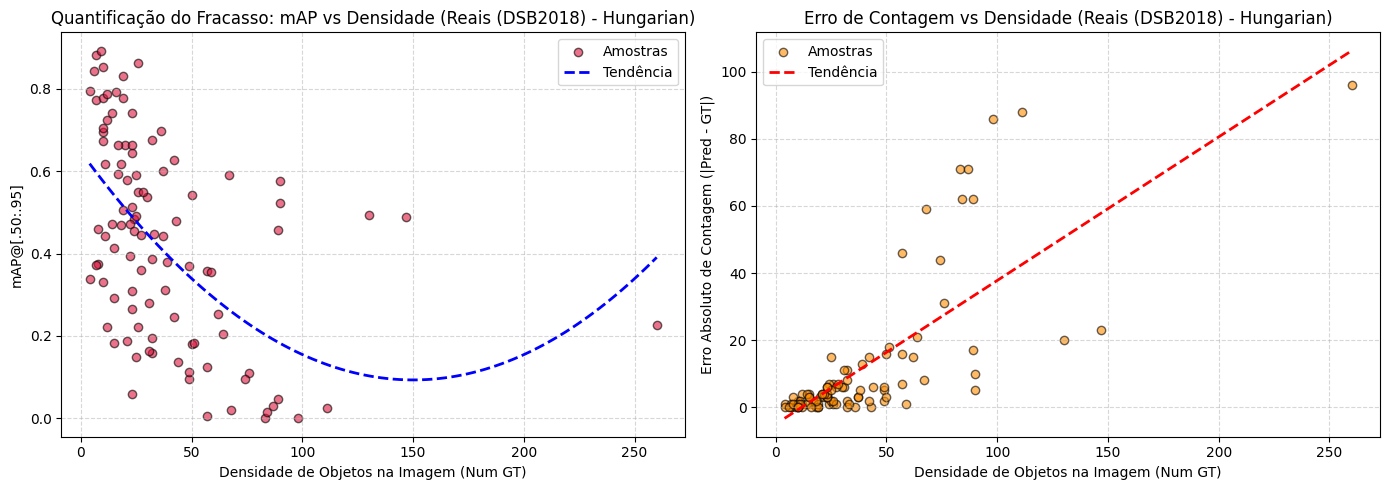

In [63]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")

---
## Parte 2 — Uma cabeça de instâncias

**Trilha escolhida:** Trilha A

Fronteiras e watershed.

In [64]:
# Parte 2 (Trilha A) — Geração dos Alvos de 3 Classes (Fundo=0, Interior=1, Fronteira=2)
y_tr_3c = utils.gerar_alvos_trilha_a(y_tr_r, border_thickness=1)
y_v_3c = utils.gerar_alvos_trilha_a(y_v_r, border_thickness=1)
y_te_3c = utils.gerar_alvos_trilha_a(y_te_r, border_thickness=1)

class_weights = utils.calcular_pesos_classes_trilha_a(y_tr_3c)
print(f"Shape treino: {y_tr_3c.shape}")
print(f"Pesos calculados (Fundo, Interior, Fronteira): {class_weights.numpy()}")

Shape treino: (468, 128, 128)
Pesos calculados (Fundo, Interior, Fronteira): [0.363606  1.1259584 1.5104355]


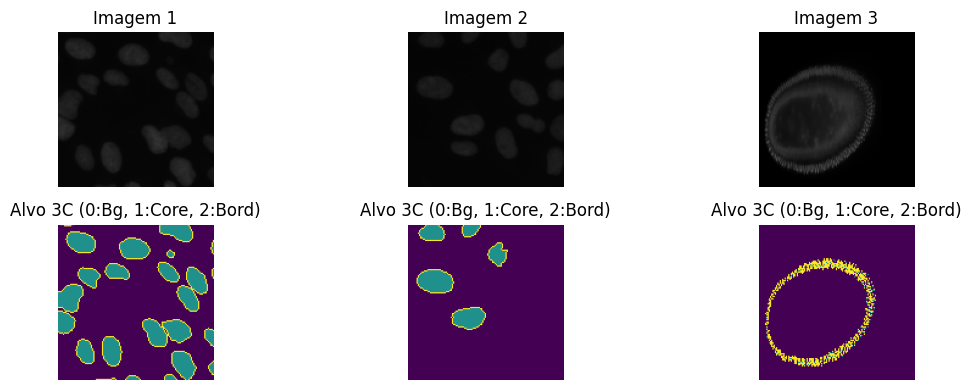

In [65]:
# Parte 2 (Trilha A) — Visualização dos Alvos de 3 Classes
utils.plot_trilha_a_samples(X_tr_r, y_tr_3c, num_samples=3)

In [66]:
# Parte 2 (Trilha A) — Treinamento ResUNet com Cross-Entropy Balanceada
head_trilha_a = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
model_trilha_a = utils.UNetResNet(head=head_trilha_a, pretrained=True, freeze_backbone=True)
utils.train_model_trilha_a_twophase(
    model_trilha_a, X_tr_r, y_tr_3c, X_v_r, y_v_3c, device,
    class_weights=class_weights, gamma=0.0,
    epochs_phase1=10, epochs_phase2=10,
    batch_size=16, lr_phase1=0.001, lr_phase2=0.0001
)


[Fase 1] Backbone CONGELADO | 10 épocas | LR=0.001
  Epoch [ 1/10] | Train: 0.3431 | Val: 0.4218
  Epoch [ 2/10] | Train: 0.2200 | Val: 0.2315
  Epoch [ 3/10] | Train: 0.1736 | Val: 0.1598
  Epoch [ 4/10] | Train: 0.1489 | Val: 0.1446
  Epoch [ 5/10] | Train: 0.1361 | Val: 0.1332
  Epoch [ 6/10] | Train: 0.1255 | Val: 0.1252
  Epoch [ 7/10] | Train: 0.1176 | Val: 0.1283
  Epoch [ 8/10] | Train: 0.1132 | Val: 0.1307
  Epoch [ 9/10] | Train: 0.1089 | Val: 0.1172
  Epoch [10/10] | Train: 0.1082 | Val: 0.1225

[Fase 2] Backbone DESCONGELADO (fine-tuning) | 10 épocas | LR=0.0001
  Epoch [ 1/10] | Train: 0.1031 | Val: 0.1095
  Epoch [ 2/10] | Train: 0.0988 | Val: 0.1085
  Epoch [ 3/10] | Train: 0.0955 | Val: 0.1113
  Epoch [ 4/10] | Train: 0.0929 | Val: 0.1107
  Epoch [ 5/10] | Train: 0.0912 | Val: 0.1093
  Epoch [ 6/10] | Train: 0.0896 | Val: 0.1092
  Epoch [ 7/10] | Train: 0.0887 | Val: 0.1089
  Epoch [ 8/10] | Train: 0.0875 | Val: 0.1045
  Epoch [ 9/10] | Train: 0.0861 | Val: 0.1041
  Ep

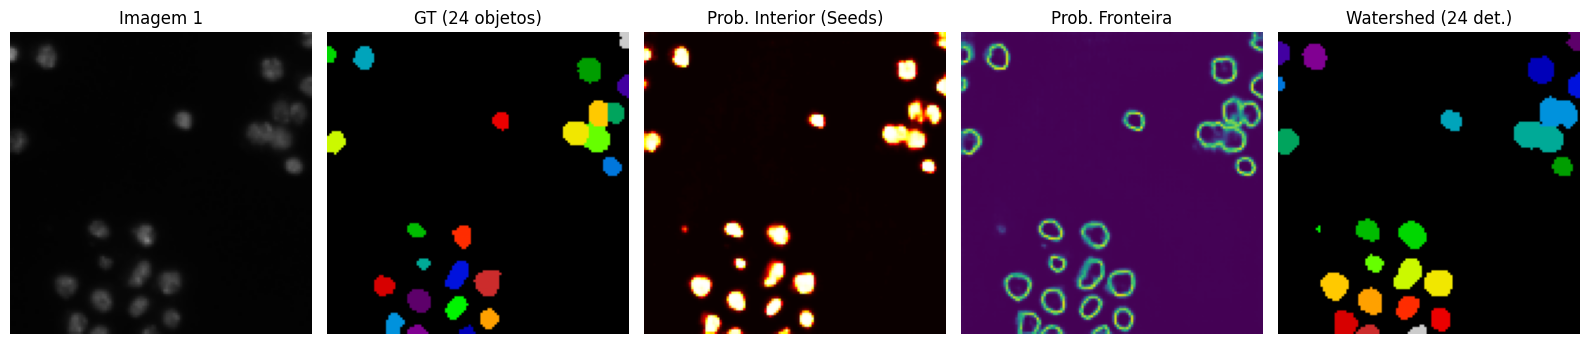

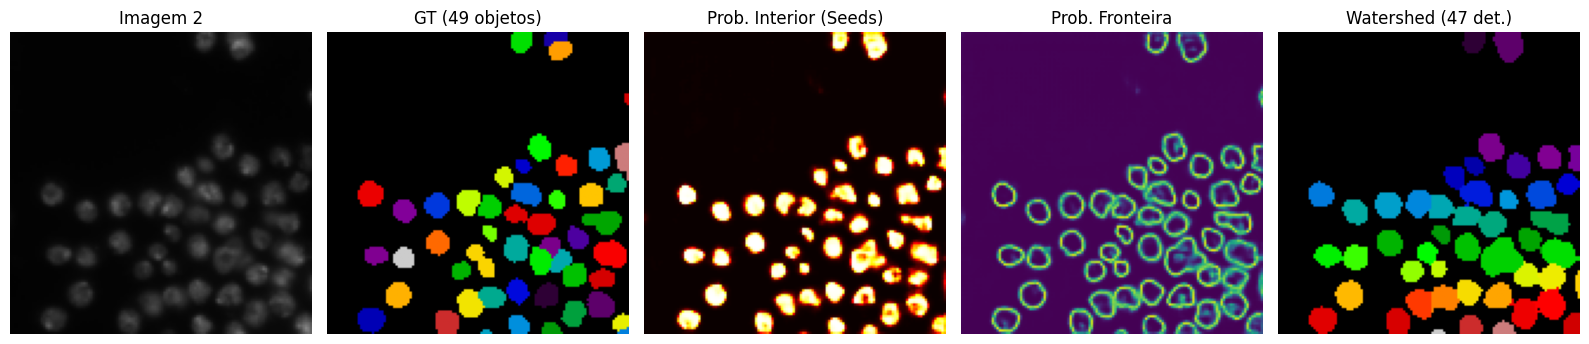

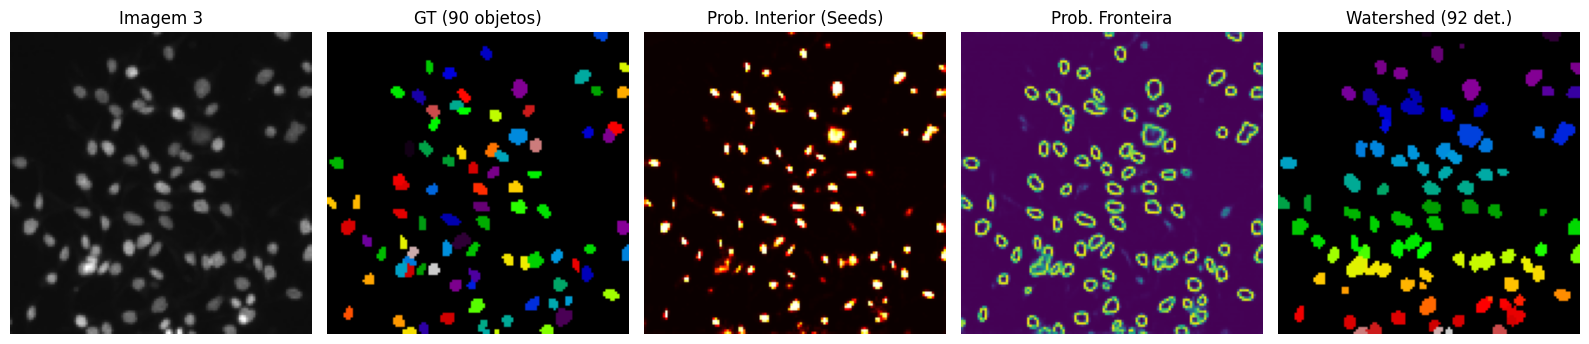

In [67]:
# Parte 2 (Trilha A) — Visualização das Predições Intermediárias e Decodificação Watershed
utils.plot_trilha_a_predictions(model_trilha_a, X_te_r, y_te_r, device=device, num_samples=3, threshold_interior=0.35, threshold_fg=0.35)

In [68]:
# Parte 2 (Trilha A) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95), mAP@[.50:.95] e Erro de Contagem
res_trilha_a = utils.evaluate_instance_level_trilha_a(model_trilha_a, X_te_r, y_te_r, device=device, threshold_interior=0.35, threshold_fg=0.35, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Parte 2 - Trilha A] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6970
  IoU = 0.55 : AP = 0.6607
  IoU = 0.60 : AP = 0.6354
  IoU = 0.65 : AP = 0.5871
  IoU = 0.70 : AP = 0.5420
  IoU = 0.75 : AP = 0.4710
  IoU = 0.80 : AP = 0.3791
  IoU = 0.85 : AP = 0.2344
  IoU = 0.90 : AP = 0.0900
  IoU = 0.95 : AP = 0.0134

--> mAP@[.50:.95] Trilha A: 0.4310
--> Erro Absoluto Médio de Contagem por Imagem: 8.32 objetos



   COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA A (Parte 2)   
                   Dataset: Reais (DSB2018)                
Métrica                             | Baseline (Ingênua)   | Trilha A (Watershed)
--------------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.4336               | 0.4310              
Erro Médio de Contagem (abs)        | 11.30                | 8.32                
AP @ IoU=0.50                       | 0.6315               | 0.6970              
AP @ IoU=0.75                       | 0.4609               | 0.4710              


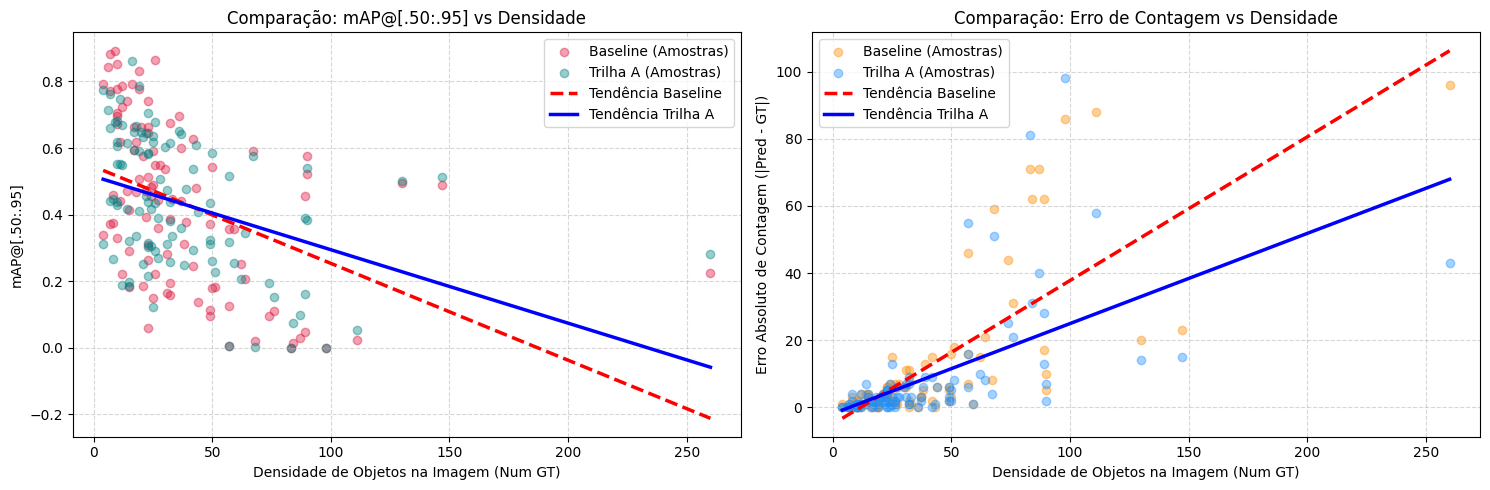

In [69]:
# Parte 2 (Trilha A) — Comparação Lado a Lado: Baseline (Parte 1) vs. Trilha A (Parte 2)
utils.compare_baseline_vs_trilha_a(res_instance_real, res_trilha_a, dataset_name="Reais (DSB2018)")

---
## Parte 3 — Ablações


**Eixos Escolhidos:**

Eixo 1: Recuperação de Resolução \
Eixo 2: Função de Perda

In [70]:
# Parte 3 (Eixo 1) — Ablação de Recuperação de Resolução: Skip Connections (U-Net) vs. Pool Indices (SegNet)
seeds_ablação = [42, 123]
resultados_eixo1 = {}

# 1. Mecanismo A: Skip Connections (U-Net / ResUNet, slides 25–29)
print("Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...")
resultados_eixo1["Skip Connections (U-Net)"] = utils.rodar_ablação_seeds(
    utils.criar_unet_res18, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.0005
)

# 2. Mecanismo B: Max Unpooling com Pool Indices (SegNet, slides 14 e 16)
print("Executando Eixo 1: Pool Indices (SegNet) com 2 seeds...")
resultados_eixo1["Pool Indices (SegNet)"] = utils.rodar_ablação_seeds(
    utils.criar_segnet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.001
)

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo1, titulo="Eixo 1: Mecanismos de Recuperação de Resolução")


Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.3673 | Val Loss: 0.4066
Epoch [ 2/12] | Train Loss: 0.2719 | Val Loss: 0.2672
Epoch [ 3/12] | Train Loss: 0.2270 | Val Loss: 0.2172
Epoch [ 4/12] | Train Loss: 0.1922 | Val Loss: 0.1937
Epoch [ 5/12] | Train Loss: 0.1682 | Val Loss: 0.1740
Epoch [ 6/12] | Train Loss: 0.1501 | Val Loss: 0.1519
Epoch [ 7/12] | Train Loss: 0.1393 | Val Loss: 0.1520
Epoch [ 8/12] | Train Loss: 0.1296 | Val Loss: 0.1524
Epoch [ 9/12] | Train Loss: 0.1233 | Val Loss: 0.1350
Epoch [10/12] | Train Loss: 0.1171 | Val Loss: 0.1345
Epoch [11/12] | Train Loss: 0.1131 | Val Loss: 0.1367
Epoch [12/12] | Train Loss: 0.1083 | Val Loss: 0.1276
Epoch [ 1/12] | Train Loss: 0.4071 | Val Loss: 0.4579
Epoch [ 2/12] | Train Loss: 0.2885 | Val Loss: 0.2666
Epoch [ 3/12] | Train Loss: 0.2422 | Val Loss: 0.2448
Epoch [ 4/12] | Train Loss: 0.2067 | Val Loss: 0.2058
Epoch [ 5/12] | Train Loss: 0.1814 | Val Loss: 0.1786
Epoch [ 6/12] | Train L

In [71]:
# Parte 3 (Eixo 2) — Ablação da Função de Perda: CE vs. CE Balanceada (α) vs. Focal (γ) vs. Focal Balanceada (α, γ)
seeds_ablação = [42, 123]
resultados_eixo2 = {}

configuracoes_perda = [
    ("CE Padrão (γ=0, sem α)", None, 0.0),
    ("CE Balanceada (γ=0, com α)", class_weights, 0.0),
    ("Focal Pura (γ=2, sem α)", None, 2.0),
    ("Focal Balanceada (γ=1, com α)", class_weights, 1.0),
    ("Focal Balanceada (γ=2, com α)", class_weights, 2.0),
    ("Focal Balanceada (γ=5, com α)", class_weights, 5.0),
]

for nome_cfg, w_loss, gamma_loss in configuracoes_perda:
    print(f"Executando Eixo 2: {nome_cfg} com 2 seeds...")
    resultados_eixo2[nome_cfg] = utils.rodar_ablação_seeds(
        utils.criar_unet_res18, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
        device, seeds=seeds_ablação, class_weights=w_loss, gamma=gamma_loss,
        num_epochs=12, batch_size=16, learning_rate=0.0005
    )

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo2, titulo="Eixo 2: Função de Perda e Desbalanceamento")


Executando Eixo 2: CE Padrão (γ=0, sem α) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.7018 | Val Loss: 0.6511
Epoch [ 2/12] | Train Loss: 0.5031 | Val Loss: 0.5693
Epoch [ 3/12] | Train Loss: 0.3791 | Val Loss: 0.4314
Epoch [ 4/12] | Train Loss: 0.2944 | Val Loss: 0.2565
Epoch [ 5/12] | Train Loss: 0.2413 | Val Loss: 0.2457
Epoch [ 6/12] | Train Loss: 0.2080 | Val Loss: 0.2063
Epoch [ 7/12] | Train Loss: 0.1859 | Val Loss: 0.1922
Epoch [ 8/12] | Train Loss: 0.1664 | Val Loss: 0.1751
Epoch [ 9/12] | Train Loss: 0.1535 | Val Loss: 0.1769
Epoch [10/12] | Train Loss: 0.1421 | Val Loss: 0.1516
Epoch [11/12] | Train Loss: 0.1332 | Val Loss: 0.1496
Epoch [12/12] | Train Loss: 0.1306 | Val Loss: 0.1496
Epoch [ 1/12] | Train Loss: 0.8240 | Val Loss: 0.8275
Epoch [ 2/12] | Train Loss: 0.5563 | Val Loss: 0.5731
Epoch [ 3/12] | Train Loss: 0.4343 | Val Loss: 0.3910
Epoch [ 4/12] | Train Loss: 0.3505 | Val Loss: 0.3174
Epoch [ 5/12] | Train Loss: 0.2907 | Val Loss: 0.2559
Epoch [ 6/12] | Train Los

---
## Parte 4 — Inferência em mosaico

In [72]:
# Parte 4 (Item 1) — Montagem de Imagem Grande em Mosaico (2x2 da Mesma Modalidade no Teste Real)
modalidades_teste = utils.identificar_modalidades(X_te_r)
indices_mosaico = np.where(modalidades_teste == 'fluorescence')[0][:4]

amostras_img = X_te_r[indices_mosaico]
amostras_mask = y_te_r[indices_mosaico]

mosaic_img, mosaic_gt = utils.criar_mosaico_imagens(amostras_img, amostras_mask, grid_shape=(2, 2))
num_gt_mosaico = len(np.unique(mosaic_gt[mosaic_gt > 0]))

print(f"Modalidade das imagens do mosaico: 'fluorescence'")
print(f"Dimensões da imagem grande: {mosaic_img.shape[:2]} | Canais: {mosaic_img.shape[2]}")
print(f"Total de núcleos reais no Ground Truth (reindexados de 1 a N): {num_gt_mosaico} objetos")


Modalidade das imagens do mosaico: 'fluorescence'
Dimensões da imagem grande: (256, 256) | Canais: 3
Total de núcleos reais no Ground Truth (reindexados de 1 a N): 175 objetos


In [73]:
# Parte 4 (Item 2) — Inferência em Tiles com Sobreposição (Slide 83 da aula)

pred_sem_fusao, semantic_prob_mosaic, tiles_data = utils.inferencia_mosaico_tiles(
    model=model_trilha_a,
    mosaic_img=mosaic_img,
    tile_size=128,
    stride=96,
    device=device,
    threshold_interior=0.35,
    threshold_fg=0.35,
    min_marker_size=1
)

num_pred_sem = len(np.unique(pred_sem_fusao[pred_sem_fusao > 0]))
print(f"Instâncias detectadas antes da correção: {num_pred_sem} (Ground Truth: {num_gt_mosaico})")

Instâncias detectadas antes da correção: 193 (Ground Truth: 175)


In [79]:
# Parte 4 (Item 3) — Fratura de Instâncias na Fronteira entre Tiles
utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=None, 
    tiles_data=tiles_data,
    tile_size=128,
    margin=25,
    corrigido=False
)

TypeError: plot_objeto_fronteira_tiles() got an unexpected keyword argument 'corrigido'

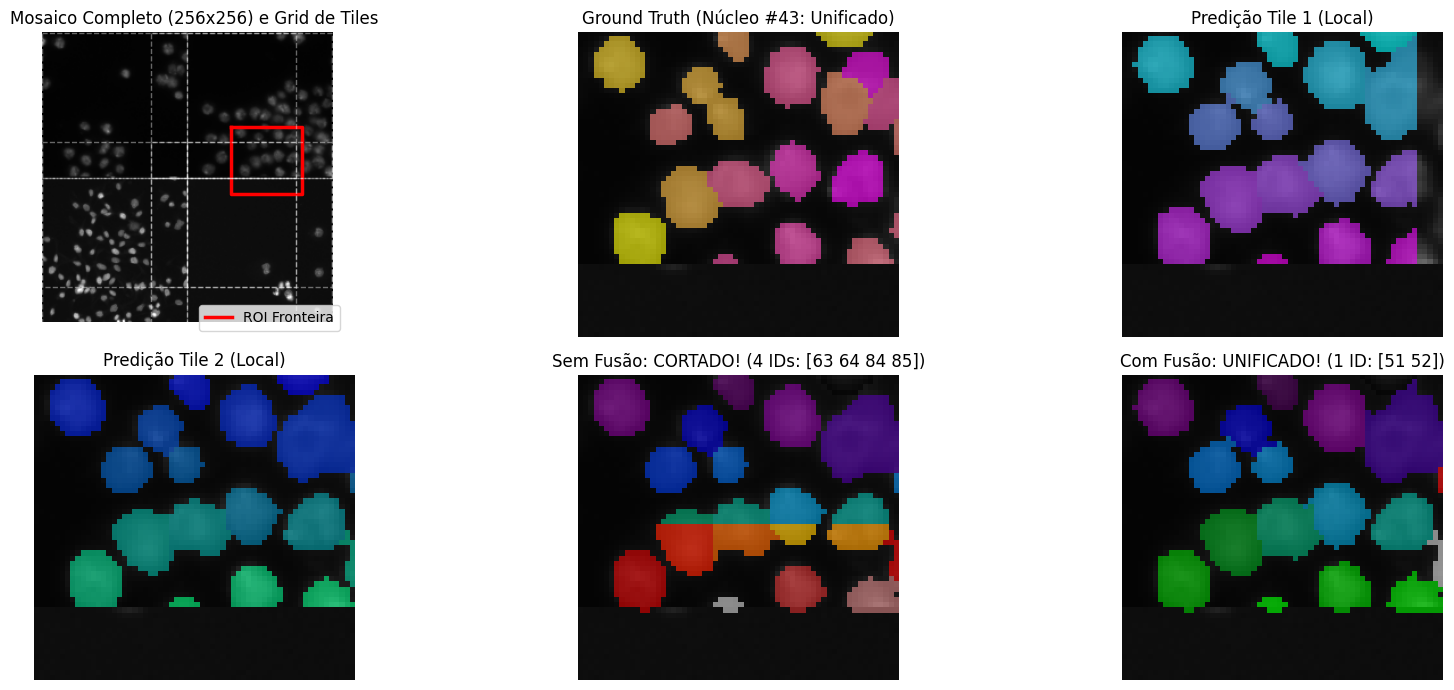


--- [Diagnóstico do Objeto na Fronteira (Item 3)] ---
Objeto GT #43 localizado na coordenada (111, 197):
 - Antes da Fusão (Slide 83): Cortado ao meio em 4 IDs independentes ([63 64 84 85]).
 - Após a Fusão (Item 4): Unificado sob o único ID global (51).

      COMPARAÇÃO NO MOSAICO: ANTES VS DEPOIS DA FUSÃO DE INSTÂNCIAS     
Métrica                             | Antes da Fusão   | Depois da Fusão  | Variação  
---------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.3162           | 0.3430           |    +0.0268
AP @ IoU=0.50                       | 0.7037           | 0.7462           |    +0.0425
AP @ IoU=0.75                       | 0.2475           | 0.2836           |    +0.0361
Número de Instâncias Preditas       | 193              | 169              |        -24
Instâncias no Ground Truth          | 175              | 175              | --        
Erro Absoluto de Contagem           | 18               | 6              

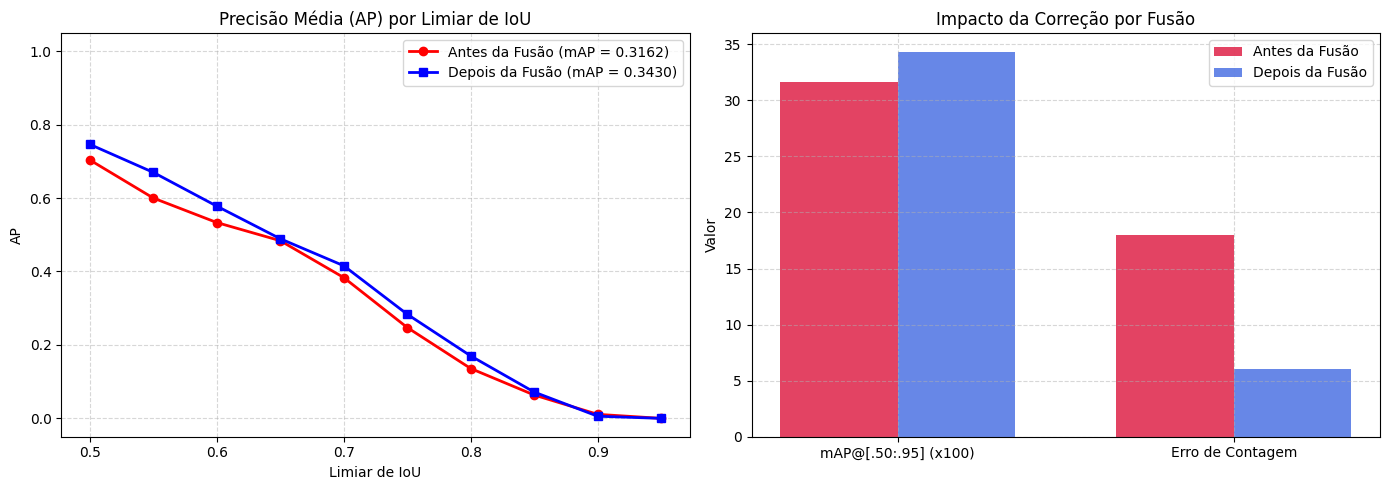

In [80]:
# Parte 4 (Item 4) — Correção via Fusão de Instâncias por IoU na Faixa de Sobreposição (Union-Find)
pred_com_fusao = utils.fundir_instancias_tiles(
    tiles_data=tiles_data,
    image_shape=mosaic_img.shape,
    tile_size=128,
    min_overlap_iou=0.20,
    min_relative_inter=0.30
)

utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    tiles_data=tiles_data,
    tile_size=128,
    margin=25
)

res_mosaico = utils.avaliar_e_comparar_mosaico(
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    matching_method="hungarian"
)

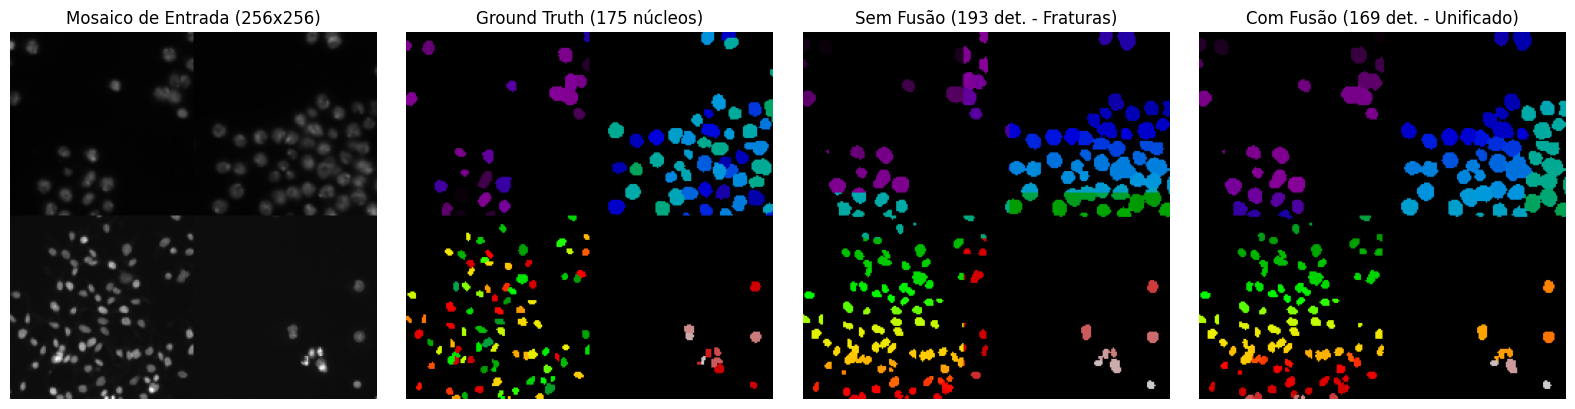

In [81]:
# Parte 4 — Visualização Geral do Mosaico Completo
utils.plot_mosaico_completo(mosaic_img, mosaic_gt, pred_sem_fusao, pred_com_fusao)

---
## Parte 5 — Galeria de falhas

   CAMPO RECEPTIVO TEÓRICO: ENCODER RESNET18 (SLIDES 35-38)
Camada                              | Kernel   | Stride   | Jump     | RF (px)   
--------------------------------------------------------------------------------
Input                               | 1        | 1        | 1        | 1         
conv1 (7x7)                         | 7        | 2        | 2        | 7         
maxpool (3x3)                       | 3        | 2        | 4        | 11        
layer1.b0.c1 (3x3)                  | 3        | 1        | 4        | 19        
layer1.b0.c2 (3x3)                  | 3        | 1        | 4        | 27        
layer1.b1.c1 (3x3)                  | 3        | 1        | 4        | 35        
layer1.b1.c2 (3x3) [Skip L1]        | 3        | 1        | 4        | 43        
layer2.b0.c1 (3x3, s2)              | 3        | 2        | 8        | 51        
layer2.b0.c2 (3x3)                  | 3        | 1        | 8        | 67        
layer2.b1.c1 (3x3)                  | 3

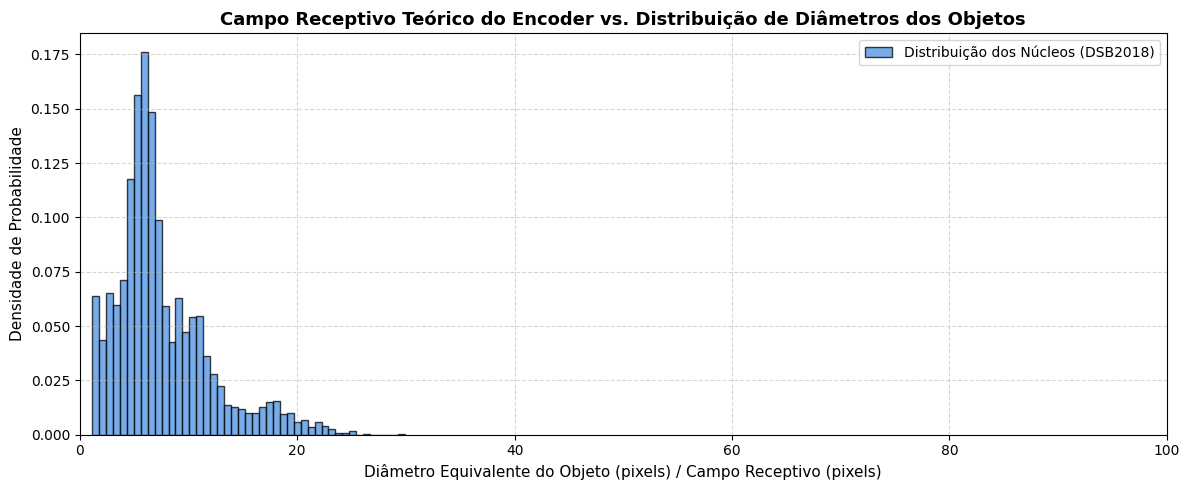


--- Estatísticas de Tamanho dos Objetos (DSB2018) ---
Total de núcleos analisados: 3852
Diâmetro Médio: 7.52 px | Mediana: 6.38 px
Diâmetro Mínimo: 1.13 px | Máximo: 29.92 px
Objetos com Diâmetro > 43 px (superam Skip L1): 0 (0.00%)


In [82]:
# Parte 5 (Item Obrigatório) — Cálculo do Campo Receptivo Teórico 
# Fórmulas de recorrência da aula:
#   j_out = j_in * s
#   r_out = r_in + (k_eff - 1) * j_in

tabela_rf = utils.calcular_campo_receptivo_resnet18()
tabela_atrous = utils.calcular_campo_receptivo_atrous()
utils.imprimir_tabela_campo_receptivo(tabela_rf, tabela_atrous)

# Extração da distribuição de diâmetros equivalentes dos núcleos no Ground Truth
diametros_gt, areas_gt = utils.extrair_diametros_objetos(y_te_r)
utils.plot_campo_receptivo_vs_dataset(diametros_gt, tabela_rf)


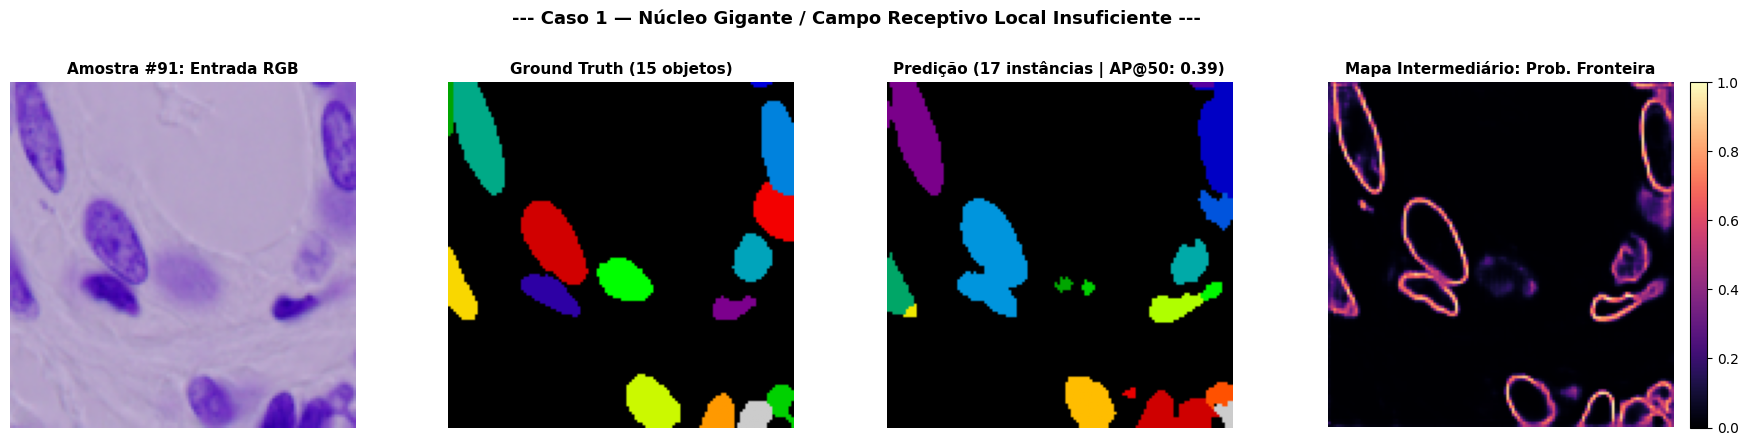

Diagnóstico Técnico: "O objeto tem diâmetro equivalente elevado (> 35-48 px). O skip connection mais resolutivo (layer1) possui campo receptivo teórico de apenas 43 px, de modo que o pixel central nunca enxerga simultaneamente as duas margens opostas. O modelo perde a coerência central e gera múltiplos marcadores espúrios, dividindo a célula."
----------------------------------------------------------------------------------------------------


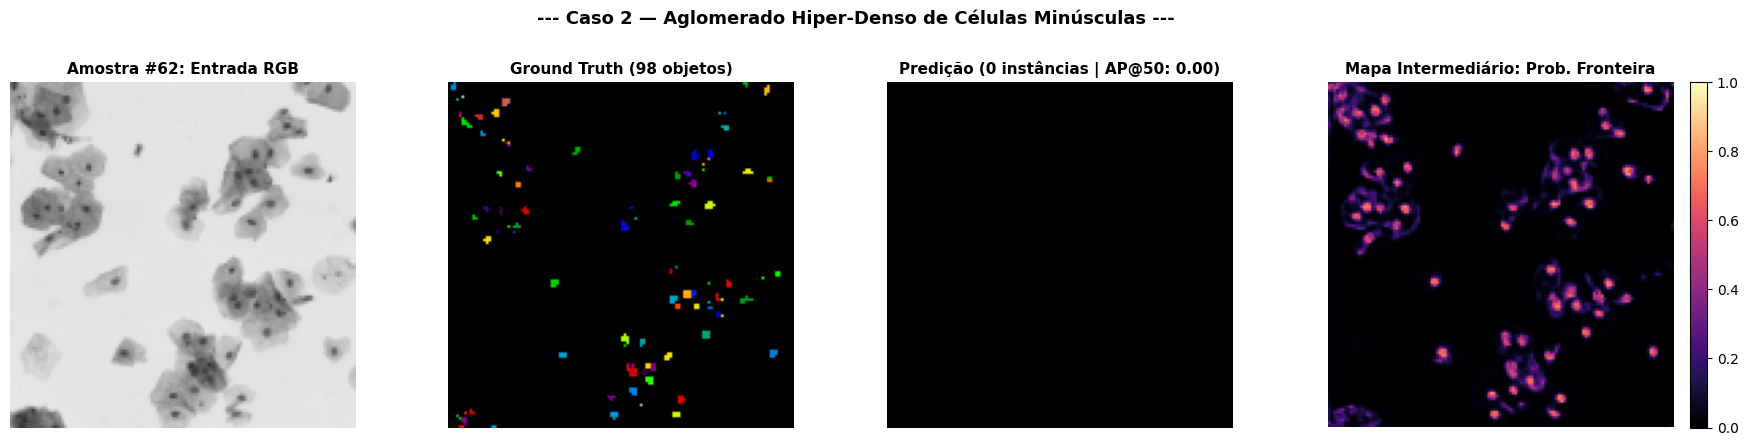

Diagnóstico Técnico: "Aglomerado com dezenas de núcleos colados (diâmetro médio <= 8 px). O stride acumulado no layer2 é 8 px e no layer3 é 16 px. A fronteira real entre eles (1 px) é suprimida pelo downsampling convolucional, gerando sub-segmentação severa e fusão de várias células sob um único rótulo (número predito muito menor que o real)."
----------------------------------------------------------------------------------------------------


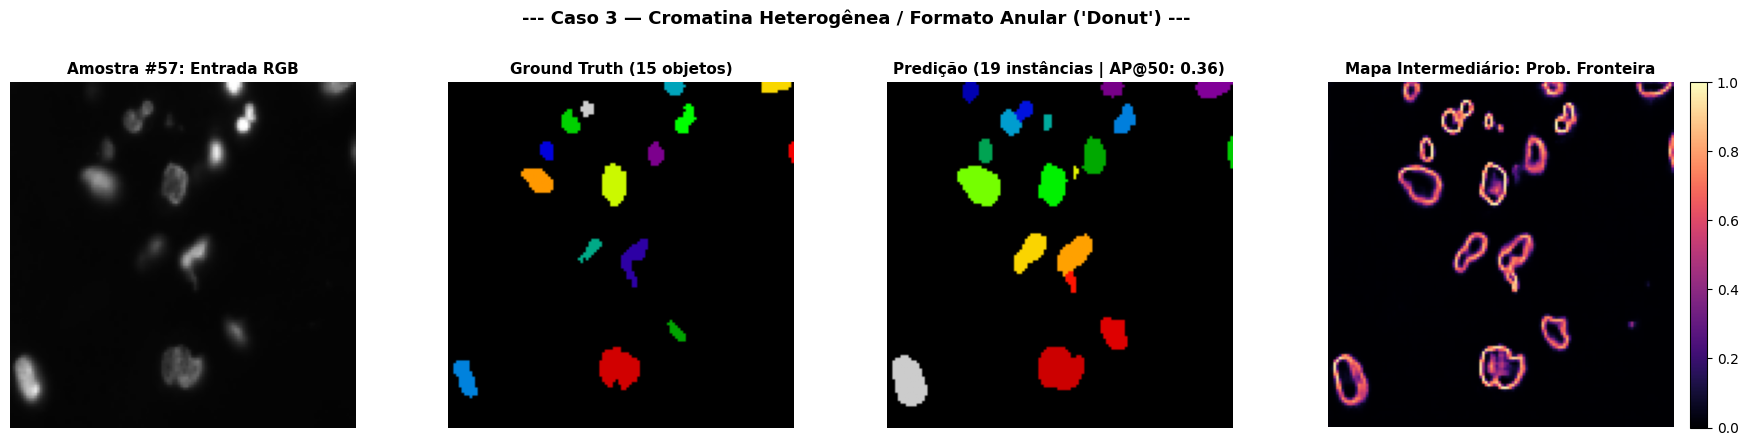

Diagnóstico Técnico: "O núcleo possui interior vacuolado com alta densidade periférica e centro claro. O mapa de probabilidade de interior produziu concavidades locais independentes. O watershed ingênuo gerou dois marcadores para um único núcleo biológico."
----------------------------------------------------------------------------------------------------


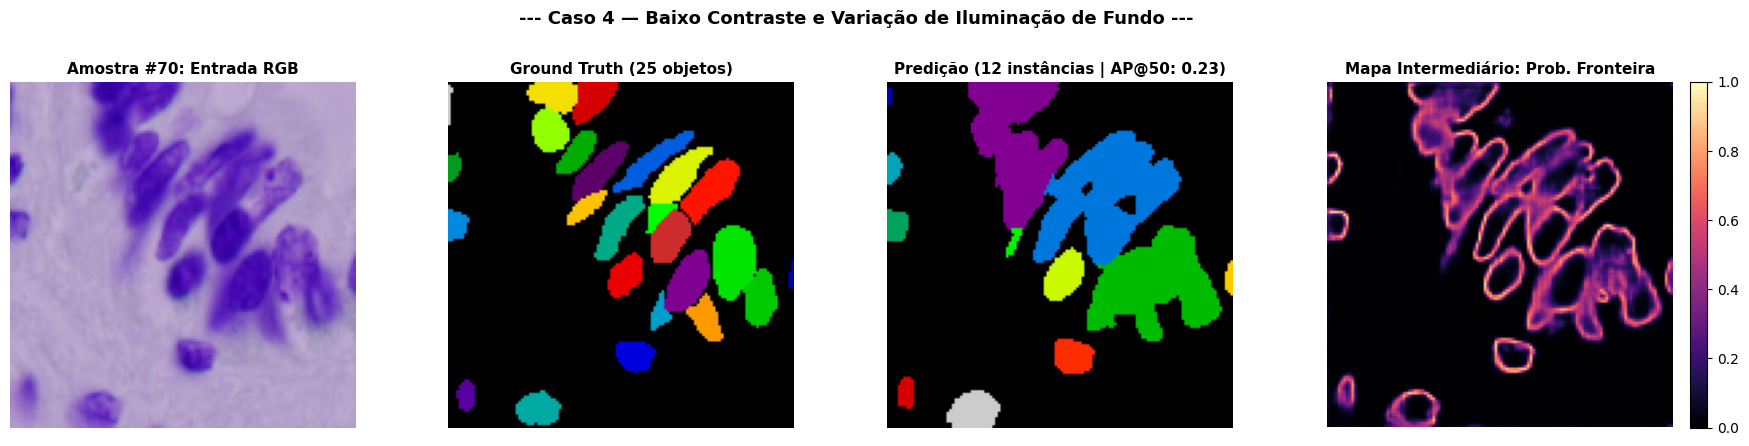

Diagnóstico Técnico: "Amostra de microscopia com baixo contraste e ruído estocástico de fundo. Gradientes espúrios na matriz extracelular foram amplificados pelo peso da classe fronteira (alpha=1.51), induzindo falsos positivos em regiões sem células."
----------------------------------------------------------------------------------------------------


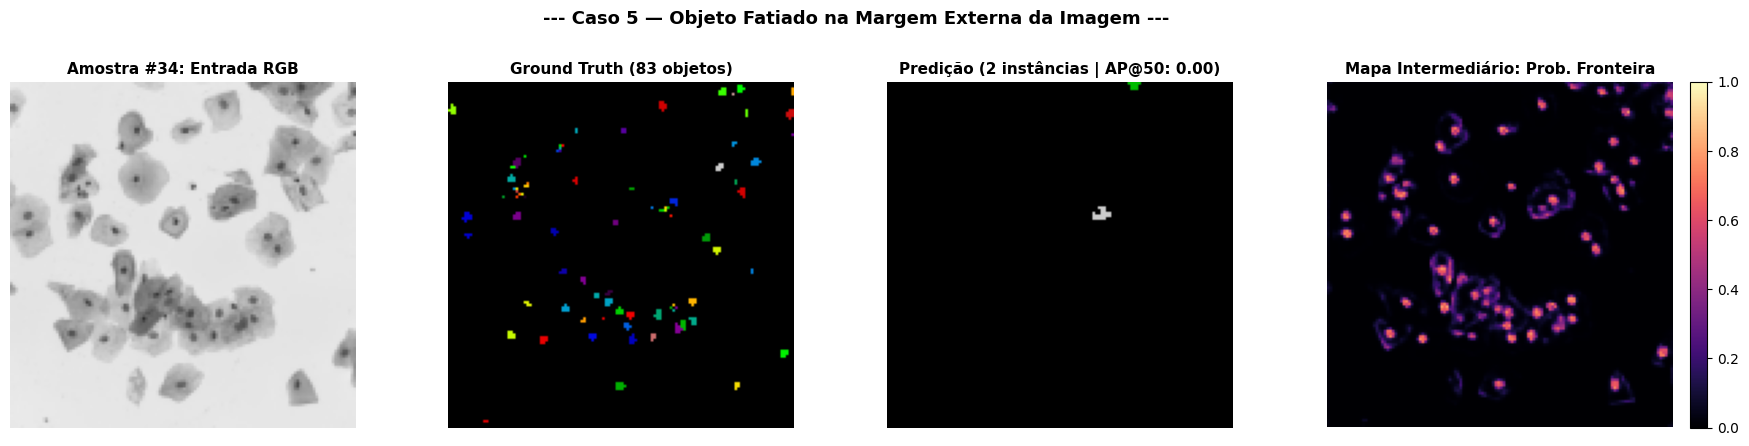

Diagnóstico Técnico: "Núcleos celulares interceptados pelas bordas da imagem (x=0 ou y=0). O zero-padding convolucional distorce os gradientes de ativação e a perda da metade externa impede o fechamento do contorno, resultando em falsos negativos."
----------------------------------------------------------------------------------------------------


In [ ]:
# Parte 5 — Mineração e Painel das 5 Piores Falhas do Modelo Final (Trilha A)
casos_falhas = utils.minerar_5_falhas_estruturais(
    model=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device
)

utils.plot_painel_5_falhas(casos_falhas)

# TODO: Achar donut e outro problema


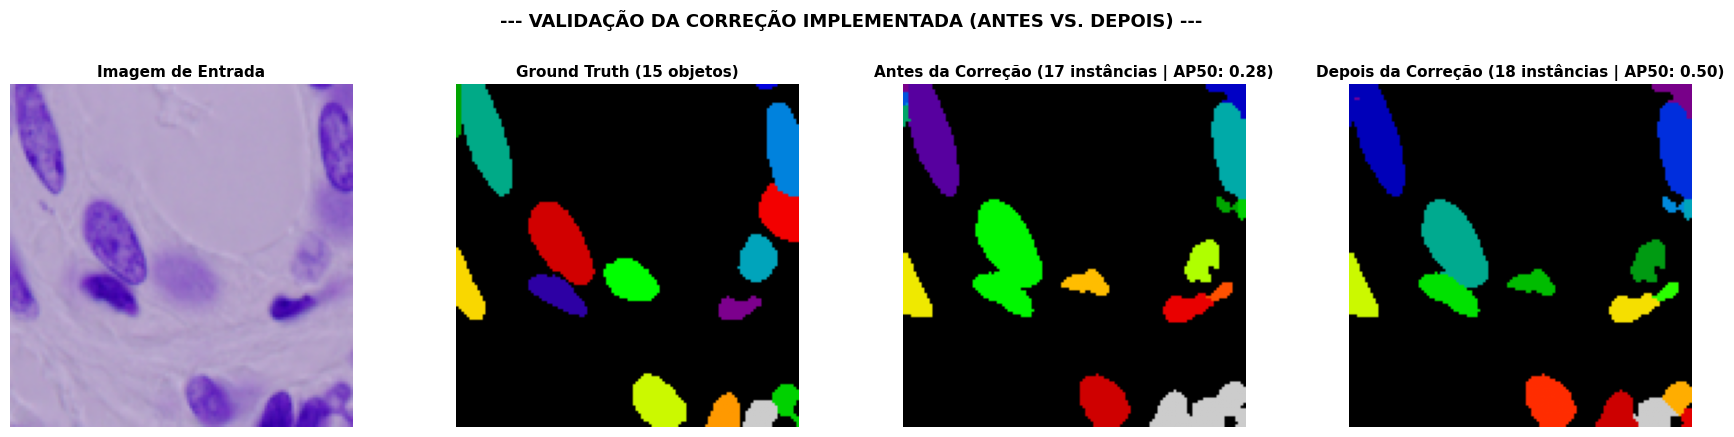

   RESULTADOS DA CORREÇÃO: SUPRESSÃO ADAPTATIVA DE MARCADORES
Métrica                 | Antes da Correção | Depois da Correção | Ganho
----------------------------------------------------------------------
AP @ IoU=0.50           | 0.2800            | 0.5000             | +0.2200
Instâncias Preditas     | 17                | 18                 | +1
Ground Truth (Real)     | 15                | 15                 | --
Erro de Contagem        | 2                 | 3                  | +1


In [ ]:
# Parte 5 — Implementação e Validação da Correção Proposta (Antes vs. Depois)
idx_caso_correcao = casos_falhas[0]["idx"]
resultado_correcao = utils.avaliar_e_plotar_correcao(
    model=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    caso_idx=idx_caso_correcao,
    device=device,
    min_distance=4
)

# TODO: Resolver outro problema

---
# Parte 6 — Teste de Estresse

**Teste escolhido:**

Mudança de modalidade

In [ ]:
# Parte 6 (Item 1) — Isolamento Estratificado das Modalidades (Treino sem "brightfield_color")
X_tr_fluo, y_tr_fluo, y_tr_3c_fluo = utils.filtrar_por_modalidade(
    X_tr_r, y_tr_r, y_tr_3c, modalidade="fluorescence", excluir=False
)
X_v_fluo, y_v_fluo, y_v_3c_fluo = utils.filtrar_por_modalidade(
    X_v_r, y_v_r, y_v_3c, modalidade="fluorescence", excluir=False
)

print(f"Treino In-Domain (Fluorescência): {X_tr_fluo.shape[0]} amostras")
print(f"Validação In-Domain (Fluorescência): {X_v_fluo.shape[0]} amostras")
print("Modalidade Omitida para Teste de Estresse: 'brightfield_color' (Campo Claro / Histologia)")

Treino In-Domain (Fluorescência): 382 amostras
Validação In-Domain (Fluorescência): 82 amostras
Modalidade Omitida para Teste de Estresse: 'brightfield_color' (Campo Claro / Histologia)


In [ ]:
# Parte 6 (Item 2) — Treinamento do Modelo U-Net (Trilha A) Exclusivamente em Fluorescência
model_stress, weights_stress = utils.treinar_modelo_modalidade(
    X_train=X_tr_fluo,
    y_train_3c=y_tr_3c_fluo,
    X_val=X_v_fluo,
    y_val_3c=y_v_3c_fluo,
    device=device,
    num_epochs=15,
    batch_size=16,
    learning_rate=0.0005,
    random_seed=42
)

Iniciando treinamento na modalidade selecionada (382 amostras de treino)...
Epoch [ 1/15] | Train Loss: 0.3472 | Val Loss: 0.3541
Epoch [ 2/15] | Train Loss: 0.2437 | Val Loss: 0.3847
Epoch [ 3/15] | Train Loss: 0.1988 | Val Loss: 0.2131
Epoch [ 4/15] | Train Loss: 0.1695 | Val Loss: 0.1952
Epoch [ 5/15] | Train Loss: 0.1491 | Val Loss: 0.1762
Epoch [ 6/15] | Train Loss: 0.1343 | Val Loss: 0.1400
Epoch [ 7/15] | Train Loss: 0.1233 | Val Loss: 0.1266
Epoch [ 8/15] | Train Loss: 0.1134 | Val Loss: 0.1179
Epoch [ 9/15] | Train Loss: 0.1068 | Val Loss: 0.1282
Epoch [10/15] | Train Loss: 0.1009 | Val Loss: 0.1197
Epoch [11/15] | Train Loss: 0.0961 | Val Loss: 0.1398
Epoch [12/15] | Train Loss: 0.0923 | Val Loss: 0.1104
Epoch [13/15] | Train Loss: 0.0897 | Val Loss: 0.1092
Epoch [14/15] | Train Loss: 0.0855 | Val Loss: 0.1033
Epoch [15/15] | Train Loss: 0.0824 | Val Loss: 0.1059


In [ ]:
# Parte 6 (Item 3) — Avaliação Quantitativa sob Mudança de Modalidade (Teste de Estresse)
res_estresse = utils.avaliar_teste_estresse_modalidade(
    model_stress=model_stress,
    model_full=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device,
    mod_treinada="fluorescence",
    mod_estresse="brightfield_color",
    threshold_interior=0.35,
    threshold_fg=0.35,
    matching_method="hungarian"
)

utils.imprimir_tabela_estresse_modalidade(res_estresse)

Avaliando Teste de Estresse:
  - In-Domain (fluorescence): 82 amostras de teste
  - Out-of-Domain / Estresse (brightfield_color): 16 amostras de teste

[1/3] Avaliando Modelo Completo (M_all) na modalidade de estresse...

[2/3] Avaliando Modelo de Estresse (M_stress) no In-Domain...

[3/3] Avaliando Modelo de Estresse (M_stress) na modalidade NÃO VISTA (Estresse)...
                    TABELA DE ESTRESSE: MUDANÇA DE MODALIDADE (fluorescence -> brightfield_color)
Configuração Experimental                    | mAP@[.5:.95] | AP@0.50  | AP@0.75  | Erro Cont.
------------------------------------------------------------------------------------------------
1. M_all (Treinado c/ Todas)  -> Teste brightfield_color | 0.2057       | 0.4034   | 0.1903   | 17.75     
2. M_stress (Treino fluorescence) -> Teste fluorescence | 0.5240       | 0.7701   | 0.5894   | 4.23      
3. M_stress (Treino fluorescence) -> Teste brightfield_color | 0.0038       | 0.0135   | 0.0006   | 26.94     
-> Degradação rel

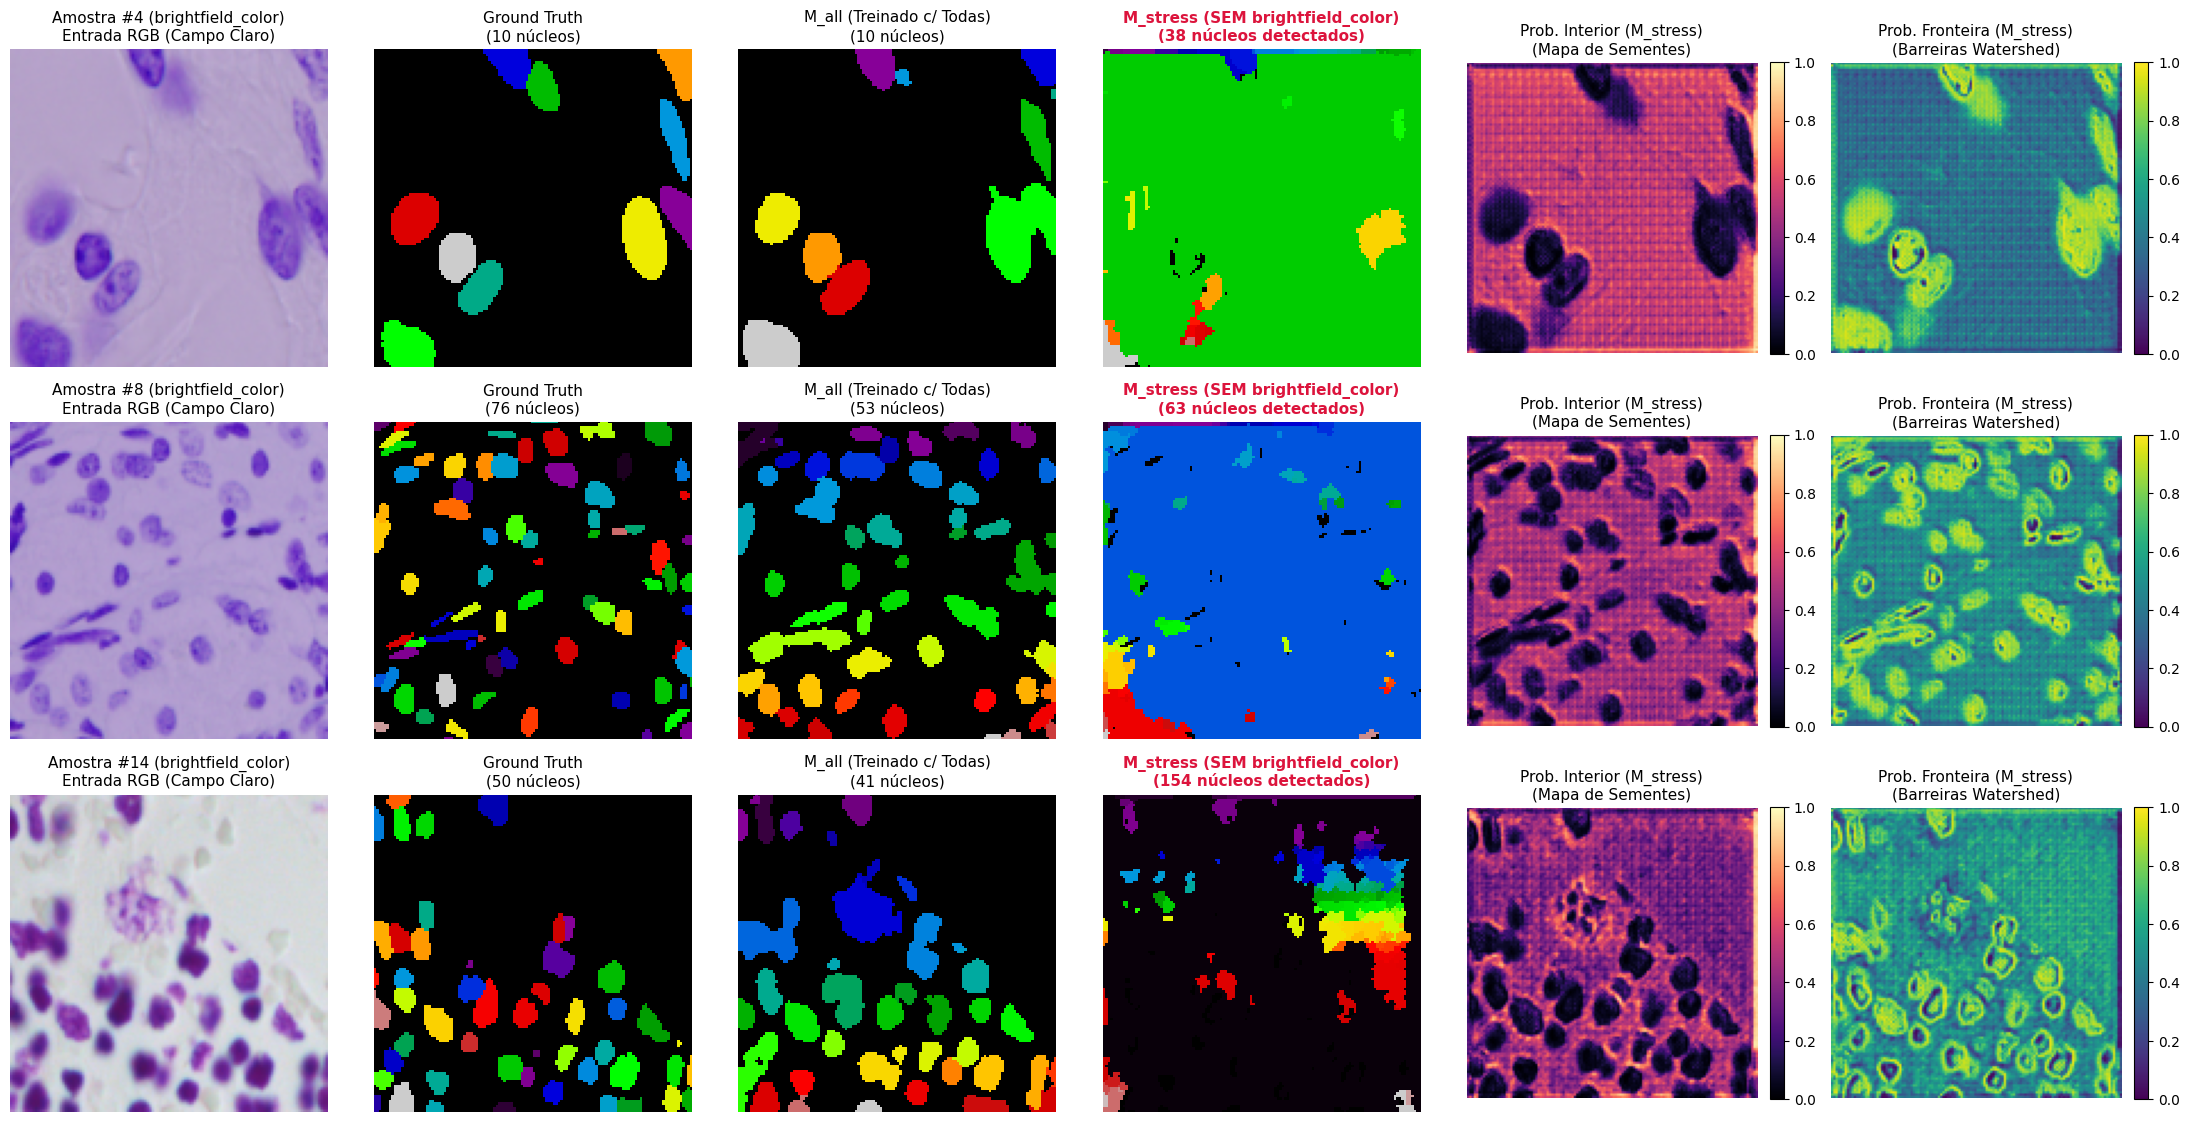

In [ ]:
# Parte 6 (Item 4) — Visualização Qualitativa do Fracasso sob Mudança de Modalidade
utils.plot_comparacao_estresse_modalidade(
    model_stress=model_stress,
    model_full=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device,
    mod_estresse="brightfield_color",
    num_samples=3
)

**CÓDIGO PARA SALVAR O MODELO:**

In [39]:
# # Recarrega o módulo utils para importar as novas funções
# import importlib
# import utils
# importlib.reload(utils)

# # Salva o checkpoint com os pesos e metadados de inferência
# caminho_ckpt = utils.salvar_checkpoint(
#     model=model_trilha_a,
#     filepath="checkpoints/checkpoint.pt",
#     threshold_interior=0.35,
#     threshold_fg=0.35
# )